In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
coordinates = pd.read_csv('../data/instances/PS10.csv', sep=';')

In [3]:
pd.read_csv('../data/data_cables.csv', sep=';').fillna(np.inf)

,cable_type,price_per_meter,max_dist_meter,max_connected_heliostats
0,copper,2.7,100.000000,2
1,glass fiber,4.0,inf,128


# clustering

In [6]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

## kmeans

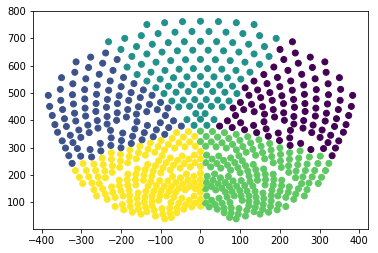

In [37]:
km = KMeans(n_clusters=5)
t = km.fit(coordinates.values)
plt.scatter(coordinates.values[:,0], coordinates.values[:,1], c=t.labels_)

## DBSCAN

In [36]:
from sklearn.preprocessing import StandardScaler

In [28]:
X = StandardScaler().fit_transform(coordinates.values)

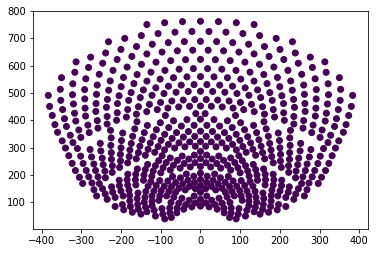

In [31]:
d = DBSCAN(eps=0.00003, min_samples=2, p=2)
t = d.fit_predict(X)
plt.scatter(coordinates.x.values, coordinates.y.values,c=t)

## AgglomerativeClustering

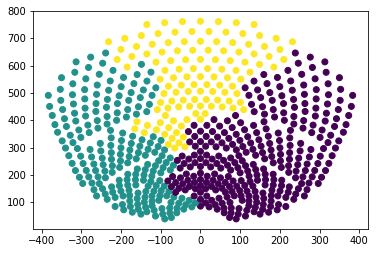

In [87]:
ac = AgglomerativeClustering(n_clusters=3, linkage='complete')
t = ac.fit(coordinates.values)
plt.scatter(coordinates.values[:,0], coordinates.values[:,1], c=t.labels_)

# distance matrix

In [91]:
import scipy
sc = scipy.spatial.distance.cdist(coordinates, coordinates, metric='euclidean')
pd.DataFrame(sc)

,0,1,2,3,4,5,6,7,8,9,...,614,615,616,617,618,619,620,621,622,623
0,0.000000,21.980439,43.596024,64.480063,84.303126,102.723194,119.432204,134.164862,146.660000,17.480174,...,346.171353,459.090194,354.211301,438.123830,361.425599,421.378290,373.980939,407.149479,385.661050,390.073698
1,21.980439,0.000000,21.982015,43.591013,64.485869,84.307535,102.722933,119.440000,134.164862,37.736306,...,343.568211,438.282917,345.109351,416.229977,348.365301,399.473632,357.566425,385.945617,366.602559,370.385159
2,43.596024,21.982015,0.000000,21.973771,43.592166,64.485088,84.300000,102.722933,119.432204,59.718133,...,347.992368,416.370854,342.739550,394.571871,341.395944,378.849826,346.302897,367.175890,351.553813,354.341143
3,64.480063,43.591013,21.973771,0.000000,21.982923,43.600000,64.485088,84.307535,102.723194,81.172658,...,358.886635,394.755135,347.382222,374.753296,341.347527,361.206498,341.463977,352.562084,342.090018,343.574162
4,84.303126,64.485869,43.592166,21.982923,0.000000,21.982923,43.592166,64.485869,84.303126,101.463898,...,375.017175,375.017175,358.471942,358.471942,348.224502,348.224502,343.636373,343.636373,339.310744,339.310744
5,102.723194,84.307535,64.485088,43.600000,21.982923,0.000000,21.973771,43.591013,64.480063,120.154069,...,394.755135,358.886635,374.753296,347.382222,361.206498,341.347527,352.562084,341.463977,343.574162,342.090018
6,119.432204,102.722933,84.300000,64.485088,43.592166,21.973771,0.000000,21.982015,43.596024,136.895053,...,416.370854,347.992368,394.571871,342.739550,378.849826,341.395944,367.175890,346.302897,354.341143,351.553813
7,134.164862,119.440000,102.722933,84.307535,64.485869,43.591013,21.982015,0.000000,21.980439,151.404190,...,438.282917,343.568211,416.229977,345.109351,399.473632,348.365301,385.945617,357.566425,370.385159,366.602559
8,146.660000,134.164862,119.432204,102.723194,84.303126,64.480063,43.596024,21.980439,0.000000,163.414677,...,459.090194,346.171353,438.123830,354.211301,421.378290,361.425599,407.149479,373.980939,390.073698,385.661050
9,17.480174,37.736306,59.718133,81.172658,101.463898,120.154069,136.895053,151.404190,163.414677,0.000000,...,338.979722,475.927780,352.161728,453.452404,362.954129,435.127222,378.943680,418.804385,393.828275,399.126434


In [78]:
coordinates.shape

(624, 2)